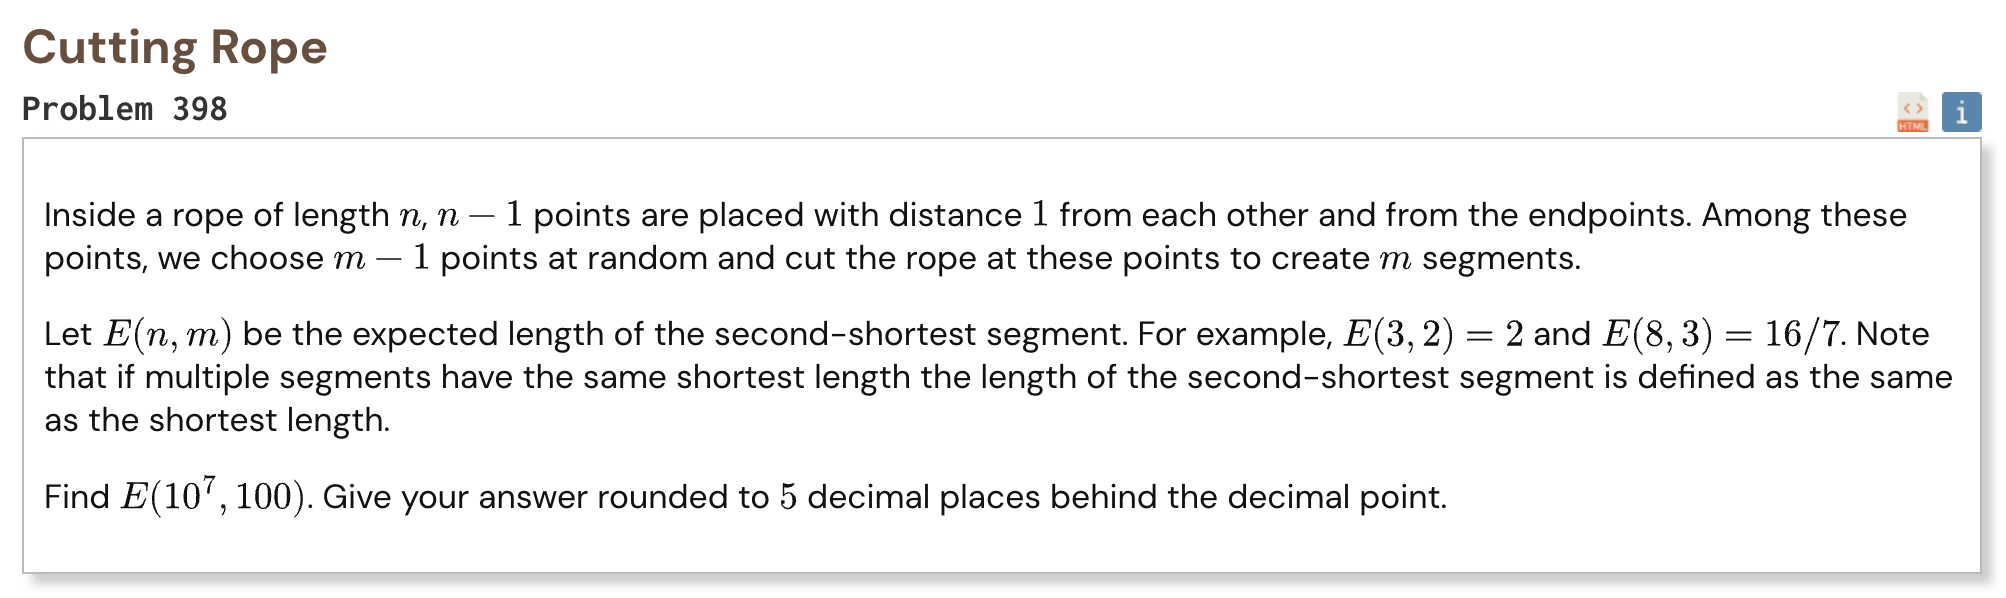

## Initial approach

-   choosing cut points is the same as choosing a random composition of n into m positive segment lengths
-   use the tail sum formula where the expectation is the sum of probabilities that the second shortest segment is at least k
-   the second shortest segment is at least k when at most one segment is smaller than k
-   count the case where every segment is at least k with stars and bars
-   count the cases where exactly one chosen segment is smaller than k
-   simplify these counts into two binomial coefficients
-   divide by the total number of possible cut selections
-   calculate binomial ratios as products of floating point fractions to avoid enormous integers

In [1]:
def binomial_ratio(top, bottom, choose):
    if top < choose:
        return 0.0

    result = 1.0

    for index in range(choose):
        result *= (top - index) / (bottom - index)

    return result


def solve(n, m):
    choose = m - 1
    denominator_top = n - 1
    result = 0.0
    maximum_k = (n - 1) // (m - 1)

    for k in range(1, maximum_k + 1):
        all_but_one_top = n - (m - 1) * k + (m - 2)
        all_top = n - m * k + (m - 1)

        all_but_one_ratio = binomial_ratio(
            all_but_one_top,
            denominator_top,
            choose
        )

        all_ratio = binomial_ratio(
            all_top,
            denominator_top,
            choose
        )

        probability = (
            m * all_but_one_ratio
            - (m - 1) * all_ratio
        )

        result += probability

    return result

In [2]:
%%time
assert abs(solve(3, 2) - 2) < 1e-12
assert abs(solve(8, 3) - 16 / 7) < 1e-12
result = solve(10 ** 7, 100)
print("Result:", f"{result:.5f}")

Result: 2010.59096
CPU times: user 1.3 s, sys: 9.77 ms, total: 1.31 s
Wall time: 1.31 s
